# Conducción de calor en 1D: <font color=green>Caso No estacionario</font> (animación)

**Trabajo realizado con el apoyo del Programa UNAM-DGAPA-PAPIME PE101019**

*   Autores: 
    - Luis M. de la Cruz Salas
*   Rev: mié 12 may 2021 16:11:52 CDT

In [1]:
#-----------------------------------------------------------
# PATH ABSOLUTO DE LOS MÓDULOS DE PYNOXTLI
#
#import os, sys
#sys.path.insert(0, os.path.abspath('../../base'))
#-----------------------------------------------------------

import numpy as np
#
# Importar módulos de pynoxtli
#
from macti.PyNoxtli.geo.line import Line
from macti.PyNoxtli.fvm.tDiffusion import tDiffusion1D
from macti.PyNoxtli.fvm.pde import PDE
from macti.PyNoxtli.utils.displayInfo import printInfo
import macti.PyNoxtli.vis.flowix as flx

In [2]:
#
# Función que ejecuta FuncAnimation() en cada paso de tiempo
#
def solver(i, ax, dt):
    laplace.solve()
    line.set_ydata(T)
    
    time_step = i * dt
    title_graf = 'Sol. Numérica :  Step = {:>3d} Time = {:>6.5f}'.format(i, time_step)
    ax.set_title(title_graf)

In [3]:
#
# Datos del problema
#
longitud = 0.5 # meters
TA = 100 # °C 
TB = 500 # °C 
k  = 1000 # W/m.K
N  = 6 # Número de nodos
dt = 0.00001 # Paso de tiempo
Tmax = 20

In [4]:
#
# Definición del dominio y condiciones de frontera
#
rod = Line(longitud)
rod.boundaryConditions(dirichlet = {'RIGHT':TB, 'LEFT':TA})
#
# Creamos la malla y obtenemos datos importantes
#
malla     = rod.constructMesh(N)
ivx, _, _ = malla.bounds(bi = 1, ei = N-1)
nx        = malla.nx    # Número de nodos
nvx       = malla.vx    # Número de volúmenes
delta     = malla.dx    # Tamaño de los volúmenes
#
# Se construye el arreglo donde se guardará la solución
#
T = np.ones(nvx+2) # El arreglo contiene unos
T *= TA          # Inicializamos T = 100
T[0]  = TA       # Condición de frontera izquierda
T[-1] = TB       # Condición de frontera derecha
#
# Imprimimos los datos del problema (nicely)
#
printInfo(Longitud = longitud,
          Temperatura_A = TA,
          Temperatura_B = TB,
          Conductividad = k,
          Nodos = nx, 
          Volúmenes = nvx,
          Delta = delta,
          dt = dt)

.--------------------------------------------------------------------------------.
|              PyNoxtli : Ver. 1.0, LMCS-2021, [GNU GPL License V3]              |
.--------------------------------------------------------------------------------.
|       Longitud = 5.000000000000000e-01                                         |
|  Temperatura_A =    100                                                        |
|  Temperatura_B =    500                                                        |
|  Conductividad =    1000                                                       |
|          Nodos =     6                                                         |
|      Volúmenes =     5                                                         |
|          Delta = 1.000000000000000e-01                                         |
|             dt = 1.000000000000000e-05                                         |
.--------------------------------------------------------------------------------.


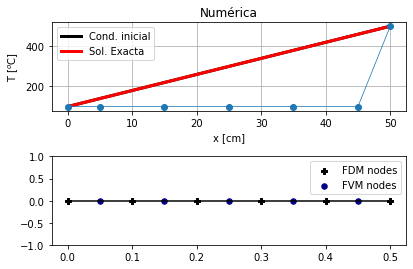

In [5]:
#
# Definimos la fuente 
#
Su = np.zeros(ivx)
#
# Definimos el esquema de disccretización
#
dif_scheme = tDiffusion1D(malla, Su, dt = dt, Gamma = k)
#
# Definimos la ecuación a resolver
#
laplace = PDE(rod, T)
#
# Preparamos el sistema lineal y creamos la matriz
#
laplace.setNumericalScheme(dif_scheme)
#
# Solución analítica
#
x, _, _ = malla.coordinatesMeshFVM()
Ta = 800 * x + 100
#
# Preparamos la visualización
#
axis_par = [{'title':'Numérica', 'xlabel':'x [cm]', 'ylabel':'T [$^o$C]'}]   
v = flx.Plotter(2,1,axis_par)
line, = v.plot(1,x * 100,T, {'marker':'o', 'ls':'-', 'lw':0.75, 'zorder':5})
#
# Resolvemos y graficamos para varios pasos de tiempo
#
v.plot(1,x * 100,Ta, {'color':'k', 'ls':'-', 'lw':3, 'label':'Cond. inicial'})        

from matplotlib.animation import FuncAnimation

anim = FuncAnimation(v.fig,    # La figura donde se hace la animación
                     solver,        # la función que resuelve y cambia los datos
                     fargs=(v.axes(1), dt, ),   # argumentos para la función solver()
                     interval=500,  # Intervalo entre cuadros en milisegundos
                     frames=Tmax+1, # Número de iteraciones (Cuadros)
                     repeat=False)  # Permite poner la animación en un ciclo 

v.plot(1,x * 100,Ta, {'color':'r', 'ls':'-', 'lw':3, 'label':'Sol. Exacta'})        
v.plot_mesh(2, malla, label=True)
v.grid()
v.legend()
v.show()

In [6]:
from IPython.display import HTML

In [7]:
HTML(anim.to_jshtml())